In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("results/results.csv")

df["model_label"] = df["guesser_model"].str.split("/").str[-1]
df["config"] = df["mode"] + "\n" + df["model_label"]

print(f"{len(df)} run(s) loaded")
df[["run_id", "seed", "mode", "model_label", "num_games", "num_wins", "avg_win_score", "co2_per_game_g"]]

1 run(s) loaded


,run_id,seed,mode,model_label,num_games,num_wins,avg_win_score,co2_per_game_g
0,slurm-5452,NaN,easy,Qwen3.5-4B,9,6,0.667,0.339777


In [3]:
df

,run_id,seed,mode,guesser_model,secret_model,num_games,num_wins,avg_win_score,avg_efficiency_score,avg_secret_reliability_score,...,avg_llm_judge_question_quality,avg_llm_judge_logical_consistency,avg_llm_judge_secret_accuracy,avg_diversity,energy_kwh,energy_per_game_wh,co2_g,co2_per_game_g,model_label,config
0,slurm-5452,NaN,easy,Qwen/Qwen3.5-4B,Qwen/Qwen3.5-4B,9,6,0.667,0.389,1.0,...,0.951,1.0,1.0,0.2331,0.02134,2.371082,3.057993,0.339777,Qwen3.5-4B,easy\nQwen3.5-4B


## 1 — Win rate by mode & model
Shows how often the guesser wins across different configurations. When multiple seeds exist, bars show the mean and error bars show standard deviation.

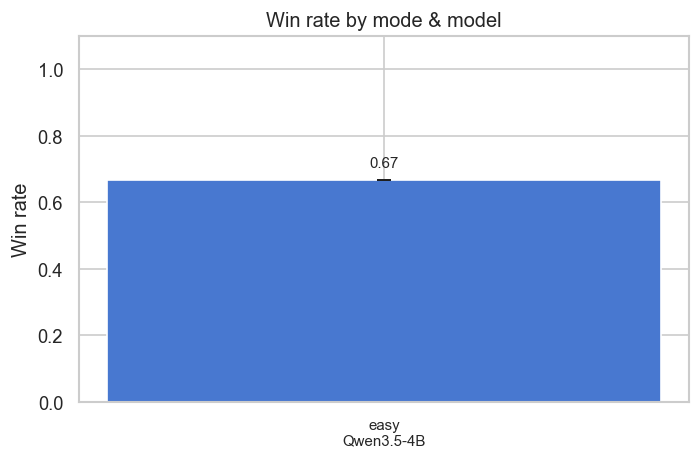

In [4]:
grouped = df.groupby(["mode", "model_label"])["avg_win_score"].agg(["mean", "std"]).reset_index()
grouped["std"] = grouped["std"].fillna(0)

fig, ax = plt.subplots(figsize=(max(6, len(grouped) * 1.2), 4))
x = np.arange(len(grouped))
bars = ax.bar(x, grouped["mean"], yerr=grouped["std"], capsize=4,
              color=sns.color_palette("muted", len(grouped)), edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"{r.mode}\n{r.model_label}" for r in grouped.itertuples()], fontsize=9)
ax.set_ylabel("Win rate")
ax.set_ylim(0, 1.1)
ax.set_title("Win rate by mode & model")
for bar, val in zip(bars, grouped["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 2 — Score breakdown per config
Compares all evaluation metrics side by side. Good for spotting whether a model is strong at one layer but weak at another.

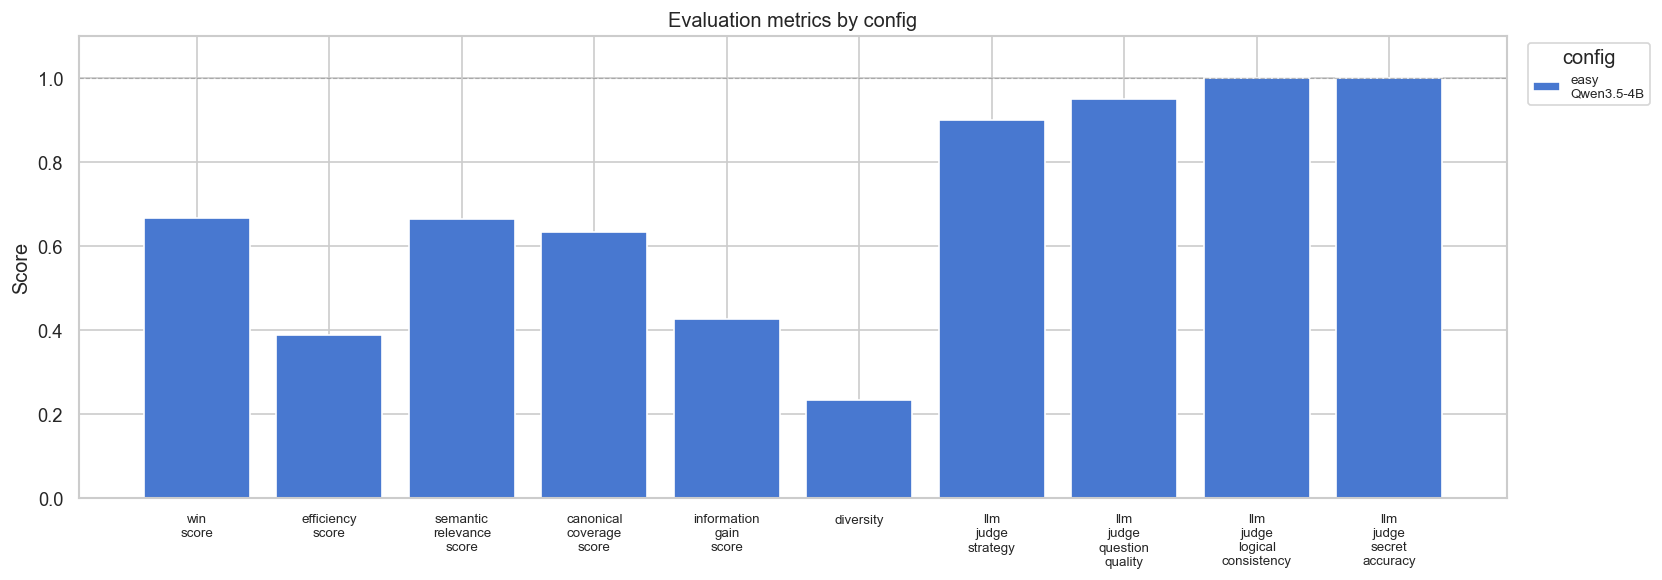

In [5]:
metrics = [
    "avg_win_score", "avg_efficiency_score",
    "avg_semantic_relevance_score", "avg_canonical_coverage_score",
    "avg_information_gain_score", "avg_diversity",
    "avg_llm_judge_strategy", "avg_llm_judge_question_quality",
    "avg_llm_judge_logical_consistency", "avg_llm_judge_secret_accuracy",
]
labels = [m.replace("avg_", "").replace("_", "\n") for m in metrics]

mean_df = df.groupby("config")[metrics].mean()

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(metrics))
width = 0.8 / max(len(mean_df), 1)
colors = sns.color_palette("muted", len(mean_df))

for i, (config, row) in enumerate(mean_df.iterrows()):
    offset = (i - len(mean_df)/2 + 0.5) * width
    ax.bar(x + offset, row[metrics], width=width, label=config, color=colors[i], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Evaluation metrics by config")
ax.legend(title="config", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()

## 3 — Seed variance (stability across runs)
When you have multiple seeds per config, this shows how stable the results are. High variance = the model is sensitive to random seed.

In [6]:
seed_metrics = ["avg_win_score", "avg_efficiency_score", "avg_diversity"]

configs_with_seeds = df.groupby("config").filter(lambda x: len(x) > 1)

if configs_with_seeds.empty:
    print("Need multiple seeds per config to show variance. Run submit_bulk_seeds.sh first.")
else:
    fig, axes = plt.subplots(1, len(seed_metrics), figsize=(14, 4), sharey=False)
    for ax, metric in zip(axes, seed_metrics):
        sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
        sns.stripplot(data=configs_with_seeds, x="config", y=metric, ax=ax,
                      color="black", size=4, alpha=0.6, jitter=True)
        ax.set_title(metric.replace("avg_", "").replace("_", " ").title())
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=8)
    plt.suptitle("Score distribution across seeds", y=1.02)
    plt.tight_layout()
    plt.show()

Need multiple seeds per config to show variance. Run submit_bulk_seeds.sh first.


## 4 — Carbon footprint
CO2 per game and total energy by config. Useful for comparing the environmental cost of larger vs smaller models.

/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_31988/4230782925.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jakobahlberg/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


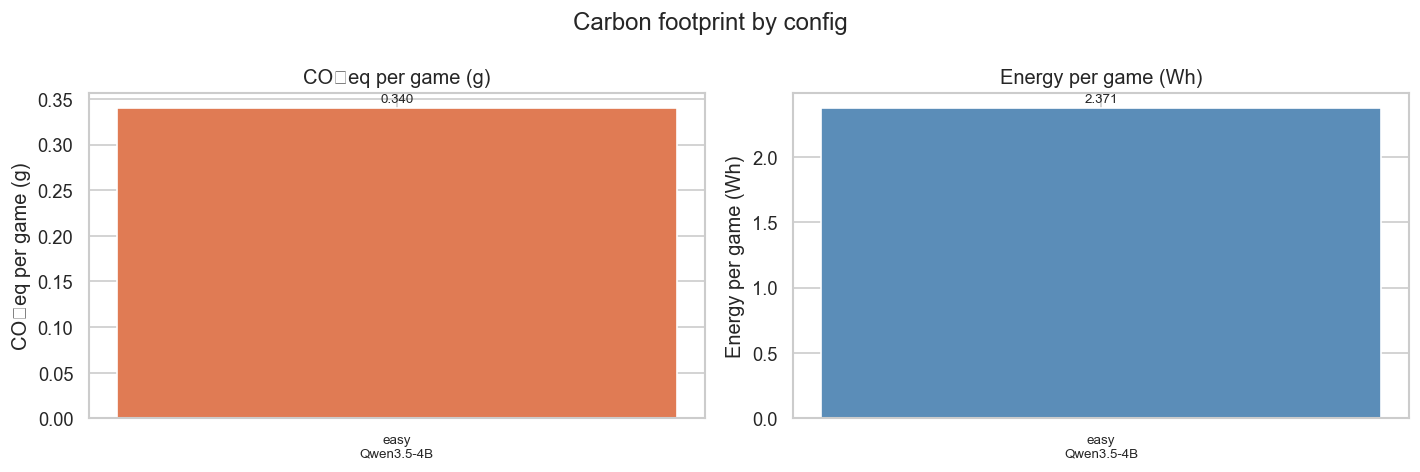

In [7]:
carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label, color in zip(
    axes,
    ["co2_per_game_g", "energy_per_game_wh"],
    ["CO₂eq per game (g)", "Energy per game (Wh)"],
    ["#e07b54", "#5b8db8"],
):
    bars = ax.bar(carbon["config"], carbon[col], color=color, edgecolor="white")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.tick_params(axis="x", labelsize=8)
    for bar, val in zip(bars, carbon[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(carbon[col])*0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Carbon footprint by config")
plt.tight_layout()
plt.show()

## 5 — Win rate vs CO₂ (efficiency frontier)
Is the better-performing model worth the extra carbon cost? Points in the top-left are ideal (high win rate, low CO₂).

/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_31988/613129743.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jakobahlberg/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


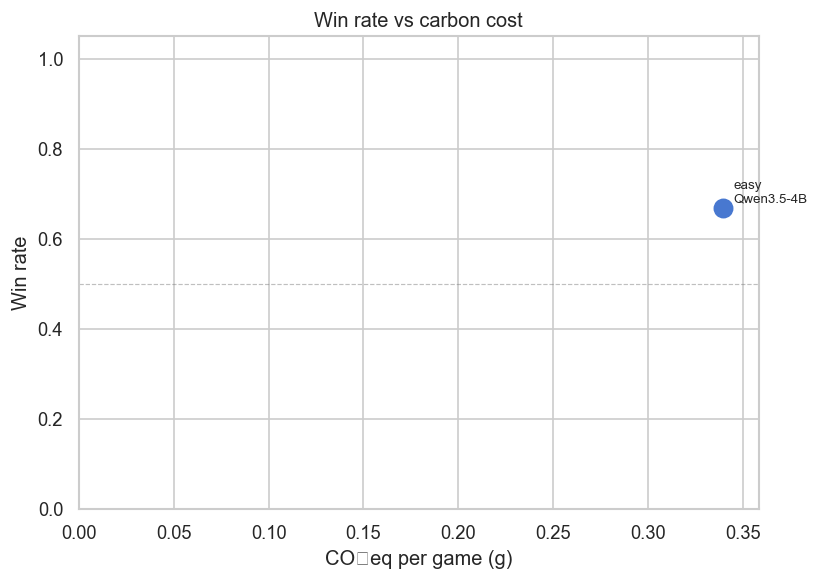

In [8]:
scatter = df.groupby("config").agg(
    win=("avg_win_score", "mean"),
    co2=("co2_per_game_g", "mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
colors = sns.color_palette("muted", len(scatter))

for i, row in scatter.iterrows():
    ax.scatter(row["co2"], row["win"], s=120, color=colors[i], zorder=3)
    ax.annotate(row["config"], (row["co2"], row["win"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("CO₂eq per game (g)")
ax.set_ylabel("Win rate")
ax.set_title("Win rate vs carbon cost")
ax.set_xlim(left=0)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()

## 6 — Metric correlation heatmap
Which metrics tend to move together? Helps understand whether the evaluation layers are measuring different things or overlapping.

## 7 — Guesser × Secret keeper win rate heatmap
Which (guesser, secret keeper) model pairings lead to the highest win rates? Each cell shows the mean win rate for that combination.

In [ ]:
pivot = df.groupby(["model_label", df["secret_model"].str.split("/").str[-1]])["avg_win_score"].mean().unstack()

if pivot.shape[0] < 2 or pivot.shape[1] < 2:
    print("Need multiple guesser and secret keeper model variants to build this heatmap.")
else:
    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1] * 1.5), max(4, pivot.shape[0] * 1.2)))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Win rate"},
    )
    ax.set_xlabel("Secret keeper model")
    ax.set_ylabel("Guesser model")
    ax.set_title("Win rate: guesser × secret keeper")
    plt.tight_layout()
    plt.show()

In [9]:
if len(df) < 3:
    print("Need at least 3 runs to compute meaningful correlations.")
else:
    corr_cols = [
        "avg_win_score", "avg_efficiency_score",
        "avg_semantic_relevance_score", "avg_canonical_coverage_score",
        "avg_information_gain_score", "avg_diversity",
        "avg_llm_judge_strategy", "avg_llm_judge_question_quality",
        "avg_llm_judge_logical_consistency", "avg_llm_judge_secret_accuracy",
        "co2_per_game_g",
    ]
    corr = df[corr_cols].corr()
    short = [c.replace("avg_", "").replace("_", "\n") for c in corr_cols]

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                xticklabels=short, yticklabels=short,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title("Metric correlation matrix")
    plt.tight_layout()
    plt.show()

Need at least 3 runs to compute meaningful correlations.
